# Modelo baseline para triagem médica

Este notebook testa o modelo central proposto para o Tech Challenge: um classificador de texto NLP leve, preparado para ser servido por uma API REST.

Fluxo executado:
1. Carregar os dados processados pelo notebook de EDA.
2. Separar treino e validação sem vazamento de dados.
3. Transformar textos em vetores TF-IDF.
4. Treinar uma Logistic Regression, adequada para inferência rápida.
5. Avaliar o modelo com métricas de classificação.
6. Medir uma inferência e salvar o pipeline para uso posterior na API.

In [1]:
# Importamos somente as bibliotecas necessárias para manter o exemplo simples.
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# O notebook está dentro de notebook/, portanto os caminhos sobem um nível
# para encontrar data/processed e models/.
PROJECT_DIR = Path.cwd().parent
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carregamento dos dados

O conjunto de treino precisa conter `text` e `urgency`. O arquivo de teste não possui rótulos, então ele será usado somente para gerar previsões depois do treinamento.

In [2]:
train_path = PROCESSED_DIR / "train.csv"
test_path = PROCESSED_DIR / "test.csv"

if not train_path.exists():
    raise FileNotFoundError(
        f"{train_path} não existe. Execute primeiro o notebook EDA."
    )

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path) if test_path.exists() else pd.DataFrame()

required_columns = {"text", "urgency"}
missing_columns = required_columns.difference(train_df.columns)
if missing_columns:
    raise ValueError(f"Colunas ausentes no treino: {missing_columns}")

train_df = train_df.dropna(subset=["text", "urgency"]).copy()
print(f"Treino: {len(train_df):,} registros")
print(f"Teste: {len(test_df):,} registros")
print(train_df["urgency"].value_counts())

Treino: 14,438 registros
Teste: 14,442 registros
urgency
urgente    6214
normal     4805
atencao    3419
Name: count, dtype: int64


## 2. Divisão treino/validação

A validação estima o comportamento em textos ainda não vistos. Usamos `stratify` para preservar a proporção das três classes. O `random_state` torna o experimento reproduzível.

In [3]:
X_train, X_valid, y_train, y_valid = train_test_split(
    train_df["text"],
    train_df["urgency"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_df["urgency"],
)

print(f"Treino: {len(X_train):,} | Validação: {len(X_valid):,}")

Treino: 11,550 | Validação: 2,888


## 3. Pipeline de NLP e treinamento

O `Pipeline` mantém o vetor TF-IDF e o classificador juntos. Isso reduz o risco de a API aplicar um pré-processamento diferente daquele usado no treinamento.

- `TfidfVectorizer`: representa palavras importantes sem guardar o texto bruto no modelo.
- `LogisticRegression`: classificador linear rápido e forte como baseline para texto.
- `class_weight="balanced"`: compensa diferenças entre os tamanhos das classes.

In [4]:
model = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=2,
            max_features=100_000,
        )),
        ("classifier", LogisticRegression(
            max_iter=1_000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]
)

# O fit aprende o vocabulário e os pesos usando apenas o subconjunto de treino.
model.fit(X_train, y_train)
print("Treinamento concluído.")

Treinamento concluído.


## 4. Avaliação

Accuracy ajuda a ter uma visão geral, mas o F1 macro é mais informativo quando todas as classes de urgência importam. O relatório detalha precisão, recall e F1 por classe.

Accuracy: 0.5589
F1 macro: 0.5420

Relatório por classe:
              precision    recall  f1-score   support

     atencao       0.46      0.55      0.50       684
      normal       0.44      0.42      0.43       961
     urgente       0.72      0.67      0.69      1243

    accuracy                           0.56      2888
   macro avg       0.54      0.55      0.54      2888
weighted avg       0.57      0.56      0.56      2888



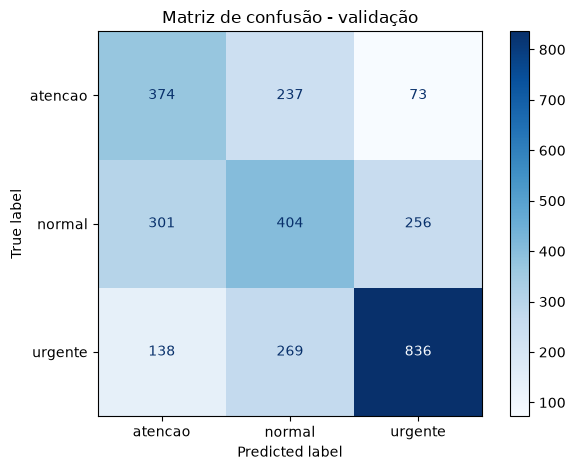

In [5]:
valid_predictions = model.predict(X_valid)
accuracy = accuracy_score(y_valid, valid_predictions)
macro_f1 = f1_score(y_valid, valid_predictions, average="macro")

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 macro: {macro_f1:.4f}")
print("\nRelatório por classe:")
print(classification_report(y_valid, valid_predictions, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    valid_predictions,
    cmap="Blues",
    values_format="d",
)
plt.title("Matriz de confusão - validação")
plt.tight_layout()
plt.show()

## 5. Teste de inferência e latência

Esta seção imita o que a API fará: receber um texto e devolver a classe prevista. A latência medida aqui é uma referência local, não substitui o benchmark dentro do container Docker.

In [6]:
def predict_urgency(text: str) -> dict[str, object]:
    """Classifica um laudo e retorna a classe e as probabilidades."""
    if not text or not text.strip():
        raise ValueError("O texto do laudo não pode ser vazio.")

    probabilities = model.predict_proba([text])[0]
    predicted_class = model.classes_[probabilities.argmax()]
    return {
        "urgency": predicted_class,
        "confidence": float(probabilities.max()),
    }

sample_text = X_valid.iloc[0]
start = perf_counter()
prediction = predict_urgency(sample_text)
latency_ms = (perf_counter() - start) * 1_000

print(f"Previsão: {prediction}")
print(f"Latência local: {latency_ms:.2f} ms")
print(f"Texto avaliado: {sample_text[:180]}...")

Previsão: {'urgency': 'atencao', 'confidence': 0.5363906958835745}
Latência local: 2.94 ms
Texto avaliado: Posttraumatic torticollis. We report six cases of torticollis precipitated by neck trauma. The dystonia began 1 to 4 days after the trauma and differed clinically from idiopathic t...


## 6. Treinamento final e persistência

Depois de escolher os hiperparâmetros usando a validação, treinamos o pipeline com todos os dados rotulados. O arquivo `.joblib` será o artefato carregado pela API FastAPI.

Não usamos o `test.csv` neste `fit`, porque ele não contém rótulos e deve permanecer reservado para previsões finais ou para o fluxo definido na entrega.

In [ ]:
final_model = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=2,
            max_features=100_000,
        )),
        ("classifier", LogisticRegression(
            max_iter=1_000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]
)
final_model.fit(train_df["text"], train_df["urgency"])

model_path = MODEL_DIR / "text_classifier.joblib"
joblib.dump(final_model, model_path)
print(f"Modelo salvo em: {model_path}")
print(f"Tamanho: {model_path.stat().st_size / 1_024**2:.2f} MB")

## 7. Comparativo com modelos alternativos

Para buscar métricas melhores que o baseline, vamos testar outros classificadores no mesmo split de validação e comparar `accuracy`, `F1 macro` e latência média de inferência.

Modelos testados:
- Logistic Regression (baseline atual)
- LinearSVC calibrado (costuma performar bem em texto)
- Complement Naive Bayes (forte baseline para bag-of-words)

In [5]:
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

candidate_models = {
    "LogReg (baseline)": Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    strip_accents="unicode",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_features=100_000,
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1_000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "LinearSVC calibrado": Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    strip_accents="unicode",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_features=100_000,
                ),
            ),
            (
                "classifier",
                CalibratedClassifierCV(
                    estimator=LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
                    method="sigmoid",
                    cv=3,
                ),
            ),
        ]
    ),
    "ComplementNB": Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    strip_accents="unicode",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_features=100_000,
                ),
            ),
            ("classifier", ComplementNB(alpha=0.5)),
        ]
    ),
}

sample_text_for_latency = X_valid.iloc[0]
benchmark_rows = []
fitted_models = {}

for model_name, pipeline in candidate_models.items():
    fit_start = perf_counter()
    pipeline.fit(X_train, y_train)
    fit_time_s = perf_counter() - fit_start

    predictions = pipeline.predict(X_valid)
    acc = accuracy_score(y_valid, predictions)
    f1_macro = f1_score(y_valid, predictions, average="macro")

    loops = 50
    latency_start = perf_counter()
    for _ in range(loops):
        pipeline.predict([sample_text_for_latency])
    latency_ms = ((perf_counter() - latency_start) / loops) * 1_000

    fitted_models[model_name] = pipeline
    benchmark_rows.append(
        {
            "model": model_name,
            "accuracy": acc,
            "f1_macro": f1_macro,
            "fit_time_s": fit_time_s,
            "avg_latency_ms": latency_ms,
        }
    )

benchmark_df = pd.DataFrame(benchmark_rows).sort_values(
    by=["f1_macro", "accuracy"], ascending=False
)
BEST_MODEL_NAME = benchmark_df.iloc[0]["model"]
BEST_VALID_MODEL = fitted_models[BEST_MODEL_NAME]

print("Comparativo de modelos (ordenado por F1 macro):")
print(
    benchmark_df.assign(
        accuracy=benchmark_df["accuracy"].round(4),
        f1_macro=benchmark_df["f1_macro"].round(4),
        fit_time_s=benchmark_df["fit_time_s"].round(2),
        avg_latency_ms=benchmark_df["avg_latency_ms"].round(3),
    ).to_string(index=False)
)
print(f"\nMelhor modelo na validação: {BEST_MODEL_NAME}")

Comparativo de modelos (ordenado por F1 macro):
              model  accuracy  f1_macro  fit_time_s  avg_latency_ms
       ComplementNB    0.5859    0.5459       20.21           9.231
  LogReg (baseline)    0.5589    0.5420       18.55           4.633
LinearSVC calibrado    0.5388    0.4967       27.46          14.193

Melhor modelo na validação: ComplementNB


In [6]:
best_model_full = clone(candidate_models[BEST_MODEL_NAME])
best_model_full.fit(train_df["text"], train_df["urgency"])

best_model_path = MODEL_DIR / "text_classifier_best.joblib"
joblib.dump(best_model_full, best_model_path)

benchmark_path = MODEL_DIR / "model_benchmark_validation.csv"
benchmark_df.to_csv(benchmark_path, index=False)

print(f"Modelo campeão treinado com todos os dados e salvo em: {best_model_path}")
print(f"Benchmark salvo em: {benchmark_path}")
print(f"Tamanho do modelo campeão: {best_model_path.stat().st_size / 1_024**2:.2f} MB")

Modelo campeão treinado com todos os dados e salvo em: c:\Users\efralmeida\OneDrive - Sefaz-SP\Documentos\Eduardo\Pessoal\Cursos\FIAP ML\Tech Challenge 03\tc3-medtriage\models\text_classifier_best.joblib
Benchmark salvo em: c:\Users\efralmeida\OneDrive - Sefaz-SP\Documentos\Eduardo\Pessoal\Cursos\FIAP ML\Tech Challenge 03\tc3-medtriage\models\model_benchmark_validation.csv
Tamanho do modelo campeão: 9.34 MB


## Conclusão

Este experimento produz o primeiro artefato funcional do projeto. Para a entrega final, ainda será necessário comparar a latência com uma versão otimizada, integrar o artefato à API FastAPI, criar testes automatizados e empacotar tudo no Docker.